In [2]:
# Titanic data set

# import all the required libraries 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
ds = pd.read_csv('titanic.csv')
ds

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
# dataset info
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## We have 7 numeric quantitative attributes and 5 qualitative attributes

In [8]:
# check for null values
ds.isna().sum()



PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
# check shape 
ds.shape

(891, 12)

In [11]:
# ckeck the column names that have numeric data type
numeric_column = ds.select_dtypes(include='number').columns.tolist()
print("Numeric columns")
for i in numeric_column:
    print(i)

Numeric columns
PassengerId
Survived
Pclass
Age
SibSp
Parch
Fare


## clean the data

In [12]:
# Fill missing 'Age' with median
ds['Age'] = ds['Age'].fillna(ds['Age'].median())

# Fill missing 'Embarked' with mode
ds['Embarked'] = ds['Embarked'].fillna(ds['Embarked'].mode()[0])

# Drop 'Cabin' column due to many missing values
ds_cleaned = ds.drop(columns=['Cabin'])

# Create a new feature 'FamilySize' (SibSp + Parch + 1 for self)
ds_cleaned['FamilySize'] = ds_cleaned['SibSp'] + ds_cleaned['Parch'] + 1

# Save cleaned data
# df_cleaned.to_csv('cleaned_titanic.csv', index=False)

C:\Users\New\AppData\Local\Temp\ipykernel_29992\1603147570.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=ds_cleaned, palette='viridis')


Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


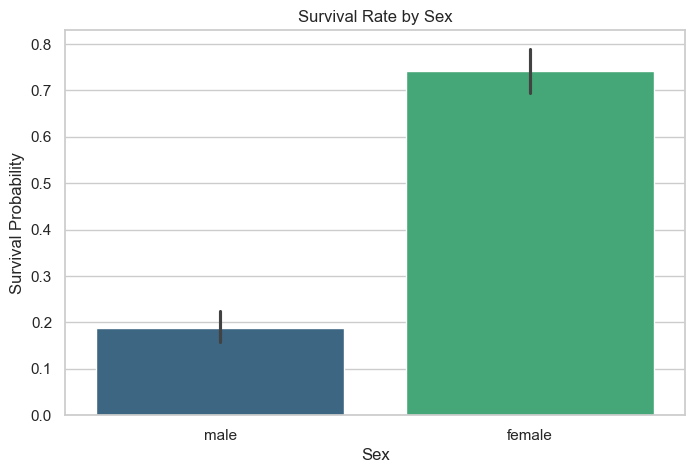

In [15]:

# 1. Visualization: Survival Rate by Sex
plt.figure(figsize=(8, 5))
sns.barplot(x='Sex', y='Survived', data=ds_cleaned, palette='viridis')
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Probability')
plt.savefig('survival_by_sex.png')

# Calculate the exact numbers for the insight
survival_stats = ds_cleaned.groupby('Sex')['Survived'].mean()
print(survival_stats)